So we need to train a model for a classic titanic survivor problem, given the ticket information and personal (age, sex, etc.) classify if the person survived on the titanic. If i correctly remember, the baseline model for this is random forest/decision tree, so we will start with it.

In [ ]:
import pandas as pd
import os
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



In [26]:
train_path = os.path.join(os.getcwd(), "data", "train.csv")
test_path = os.path.join(os.getcwd(), "data", "test.csv")
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
test_passenger_id = test["PassengerId"]

In [27]:
def preprocess_data(data:pd.DataFrame) -> pd.DataFrame:
    clean = data
    clean = clean.drop(["PassengerId", "Name", "Ticket", "Cabin", "SibSp"], axis=1)
    le = LabelEncoder()
    clean["Sex"] = le.fit_transform(data["Sex"])
    clean["Embarked"] = le.fit_transform(data["Embarked"])
    clean["Age"] = clean["Age"].fillna(data["Age"].mean())
    clean["Fare"] = clean["Fare"].fillna(data["Fare"].mean())
    return clean

In [28]:
preprocessed_train = preprocess_data(train)
X_train, y_train  = preprocessed_train.iloc[:, 1:], preprocessed_train.iloc[:, 0]
X_test = preprocess_data(test)

print(X_test.head(), X_test.shape)
print(y_train.head(), y_train.shape)
print(X_train.head(), X_train.shape)


   Pclass  Sex   Age  Parch     Fare  Embarked
0       3    1  34.5      0   7.8292         1
1       3    0  47.0      0   7.0000         2
2       2    1  62.0      0   9.6875         1
3       3    1  27.0      0   8.6625         2
4       3    0  22.0      1  12.2875         2 (418, 6)
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64 (891,)
   Pclass  Sex   Age  Parch     Fare  Embarked
0       3    1  22.0      0   7.2500         2
1       1    0  38.0      0  71.2833         0
2       3    0  26.0      0   7.9250         2
3       1    0  35.0      0  53.1000         2
4       3    1  35.0      0   8.0500         2 (891, 6)


In [41]:
decission_tree = DecisionTreeClassifier(criterion="gini", max_depth=3).fit(X_train, y_train)
print("training score: ", decission_tree.score(X_train, y_train))
dt_prediction = decission_tree.predict(X_test)
dt_prediction = pd.DataFrame(dt_prediction, columns=['Survived'])

dt_prediction.insert(0, "PassengerId", test_passenger_id)
dt_prediction.to_csv(os.path.join(os.getcwd(), "submissions", "dt_submission.csv"), index=False)

training score:  0.8215488215488216


Test score is 0.7799
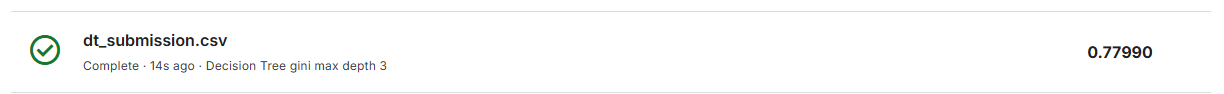

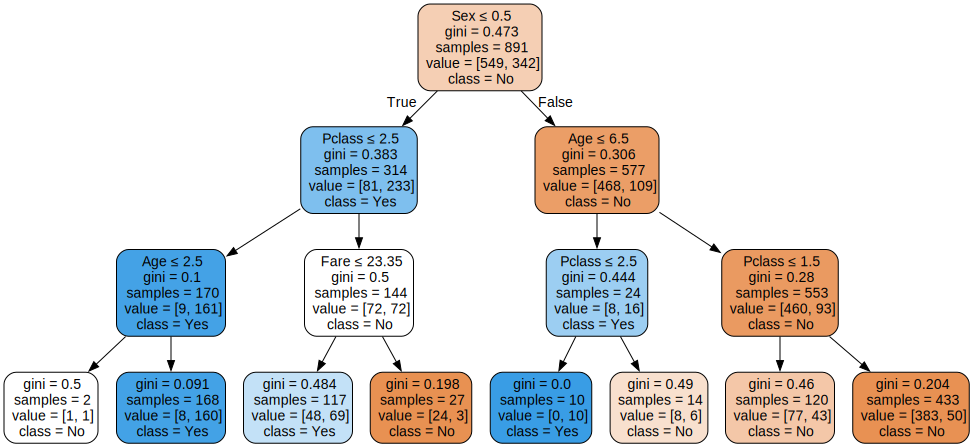

In [38]:
features = list(X_train)[:7]
dot_data = export_graphviz(decission_tree,
                           out_file=None,
                           feature_names=list(features),
                           class_names=["No", "Yes"], 
                            filled=True, 
                            rounded=True,  
                            special_characters=True)
graph = graphviz.Source(dot_data)
display(graph)

In [42]:
random_forest = RandomForestClassifier(criterion="log_loss", max_depth = 5, n_estimators=160)
random_forest.fit(X_train, y_train)
print("training score: ", random_forest.score(X_train, y_train))
rf_prediction = random_forest.predict(X_test)
rf_prediction = pd.DataFrame(rf_prediction, columns=['Survived'])

rf_prediction.insert(0, "PassengerId", test_passenger_id)
rf_prediction.to_csv(os.path.join(os.getcwd(), "submissions", "rf_submission.csv"), index=False)

training score:  0.8484848484848485


test_score 0.78229
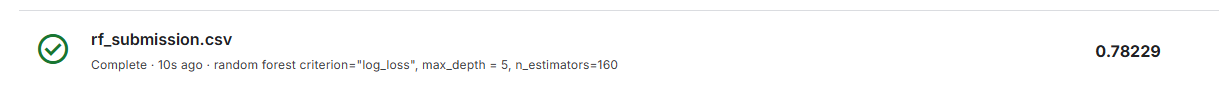

I believe you cant achieve very high accuracy here, because after all death is not very predictable, sometimes its just luck, correct time or place.

In [46]:

xgb = XGBClassifier(alpha=0, gamma=1, max_depth=3)
xgb.fit(X_train, y_train)
print("training score: ", xgb.score(X_train, y_train))
xgb_prediction = xgb.predict(X_test)
xgb_prediction = pd.DataFrame(xgb_prediction, columns=['Survived'])

xgb_prediction.insert(0, "PassengerId", test_passenger_id)
xgb_prediction.to_csv(os.path.join(os.getcwd(), "submissions", "xgb_submission.csv"), index=False)

training score:  0.8540965207631874


test score 0.7775
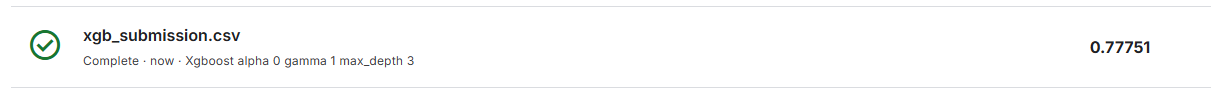

Worse than random forest by 0.05%, i would say that is no difference on 800 samples, and still 80% limit, i guess it's just how much we can get from that information.